# Bayesian Generalized Linear Model (Logistic Regression) using NumPyro

### データセット
* Pima Indians Diabetes Dataset

### モデル
* ベイズロジスティック回帰 (弱情報事前分布)

### データ分割
* train 60% / validation 20% / test 20%

In [ ]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_median
from numpyro.diagnostics import hpdi
import arviz as az
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, log_loss,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import japanize_matplotlib
import warnings
warnings.filterwarnings("ignore")

# ── 再現性 ──────────────────────────────────────────────────────────────────
SEED = 1234
rng_key = jax.random.PRNGKey(SEED)

In [2]:
df = pd.read_csv("diabetes.csv")
print(f"データ形状: {df.shape}")
print(df.head())

データ形状: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
TARGET_COL = "Outcome"
FEATURE_COLS = [col for col in df.columns if col != TARGET_COL]

X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.float32)

# stratifyは使わない。テストセットのOutcomeはどうなっているか分からないため。
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=123
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
)

print(f"\nデータ分割: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")

# imputation (中央値で補完)
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

# 標準化 (train の統計量で fit)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)


データ分割: train=489, val=163, test=116


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. モデル定義
# ─────────────────────────────────────────────────────────────────────────────
def bayesian_logistic_regression(X, y=None):
    """
    ベイズロジスティック回帰

    事前分布 (弱情報事前分布):
        intercept  ~ Normal(0, 2.5)
        weights    ~ Normal(0, 2.5)  [各特徴量独立]

    尤度:
        y ~ Bernoulli(sigmoid(X @ weights + intercept))
    """
    n_features = X.shape[1]

    # 事前分布
    intercept = numpyro.sample("intercept", dist.Normal(0.0, 1.0))
    weights   = numpyro.sample("weights",   dist.Normal(
        jnp.zeros(n_features), 1.0 * jnp.ones(n_features)
    ))

    # 線形予測子 (n,)
    logits = jnp.dot(X, weights) + intercept

    # 尤度: plate を使わず obs に配列を直接渡す
    obs_y = jnp.array(y, dtype=jnp.float32) if y is not None else None
    numpyro.sample("y", dist.Bernoulli(logits=logits).to_event(0), obs=obs_y)

In [5]:
# 階層的事前分布バージョン (horseshoe-like scale mixture)
def bayesian_logistic_regression_hierarchical(X, y=None):
    """
    階層的ベイズロジスティック回帰 — Non-centered parameterization (NCP)

    Centered parameterization (CP) の問題:
        w_j ~ Normal(0, tau * lam_j) を直接サンプルすると、
        tau * lam_j が小さいとき事後分布が極端に細い谷 (Neal's funnel) になり
        NUTSが発散しやすい。

    Non-centered parameterization (NCP) による解決:
        補助変数 weights_raw ~ Normal(0, 1) をサンプルし、
        weights = weights_raw * tau * lam  と決定論的に変換する。
        これにより weights_raw の事後分布は tau・lam に依存せず、
        NUTSが効率的にサンプリングできる geometry になる。

    事前分布:
        tau         ~ HalfNormal(1.0)          — グローバルスケール
                       (HalfCauchyより裾が軽く、funnel緩和に有効)
        lam_j       ~ HalfNormal(1.0)          — 局所スケール
        weights_raw ~ Normal(0, 1)             — 補助変数 (標準正規)
        weights     = weights_raw * tau * lam  — 決定論的変換
        intercept   ~ Normal(0, 1.0)
    """
    n_features = X.shape[1]

    # ── スケールパラメータ ──────────────────────────────────────────
    # HalfCauchy は裾が重すぎて funnel を悪化させることがあるため
    # HalfNormal(1.0) を使用（より保守的な正則化）
    tau = numpyro.sample("tau", dist.HalfNormal(1.0))
    lam = numpyro.sample("lam", dist.HalfNormal(jnp.ones(n_features)))

    # ── Non-centered parameterization ──────────────────────────────
    # weights_raw は tau・lam と独立な標準正規 → geometry が滑らか
    weights_raw = numpyro.sample(
        "weights_raw", dist.Normal(jnp.zeros(n_features), jnp.ones(n_features))
    )
    # 決定論的変換: numpyro.deterministic で事後サンプルに記録
    weights = numpyro.deterministic("weights", weights_raw * tau * lam)

    intercept = numpyro.sample("intercept", dist.Normal(0.0, 1.0))

    # ── 尤度 ────────────────────────────────────────────────────────
    logits = jnp.dot(X, weights) + intercept

    obs_y = jnp.array(y, dtype=jnp.float32) if y is not None else None
    numpyro.sample("y", dist.Bernoulli(logits=logits).to_event(0), obs=obs_y)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. MCMC (NUTS) によるサンプリング
# ─────────────────────────────────────────────────────────────────────────────
def run_mcmc(model, X_train, y_train, num_warmup=1000, num_samples=2000,
             num_chains=4, model_name="model"):
    print(f"\n{'='*60}")
    print(f"  {model_name} — MCMC (NUTS) 開始")
    print(f"  warmup={num_warmup}, samples={num_samples}, chains={num_chains}")
    print(f"{'='*60}")

    kernel = NUTS(model, init_strategy=init_to_median())
    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        progress_bar=True,
    )
    rng_key_ = jax.random.PRNGKey(SEED)
    X_jnp = jnp.array(X_train, dtype=jnp.float32)
    y_jnp = jnp.array(y_train, dtype=jnp.float32)
    mcmc.run(rng_key_, X=X_jnp, y=y_jnp)
    mcmc.print_summary(prob=0.9)
    return mcmc

In [7]:
# ── モデル 1: 弱情報事前分布 ──
mcmc_flat = run_mcmc(
    bayesian_logistic_regression,
    X_train_s, y_train,
    model_name="Bayesian Logistic Regression (Weakly Informative Prior)"
)


  Bayesian Logistic Regression (Weakly Informative Prior) — MCMC (NUTS) 開始
  warmup=1000, samples=2000, chains=4


sample: 100%|██████████| 3000/3000 [00:00<00:00, 4660.83it/s, 7 steps of size 5.55e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
  intercept     -0.90      0.12     -0.90     -1.09     -0.69  12099.04      1.00
 weights[0]      0.35      0.13      0.34      0.11      0.55   9620.39      1.00
 weights[1]      1.17      0.15      1.17      0.94      1.41  11030.46      1.00
 weights[2]     -0.17      0.13     -0.17     -0.39      0.03  10232.25      1.00
 weights[3]     -0.02      0.13     -0.02     -0.24      0.20   8942.52      1.00
 weights[4]     -0.11      0.13     -0.11     -0.32      0.12   9270.82      1.00
 weights[5]      0.60      0.14      0.60      0.36      0.84  11449.24      1.00
 weights[6]      0.26      0.12      0.26      0.05      0.46  12249.22      1.00
 weights[7]      0.20      0.14      0.20     -0.03      0.43   7934.45      1.00

Number of divergences: 0


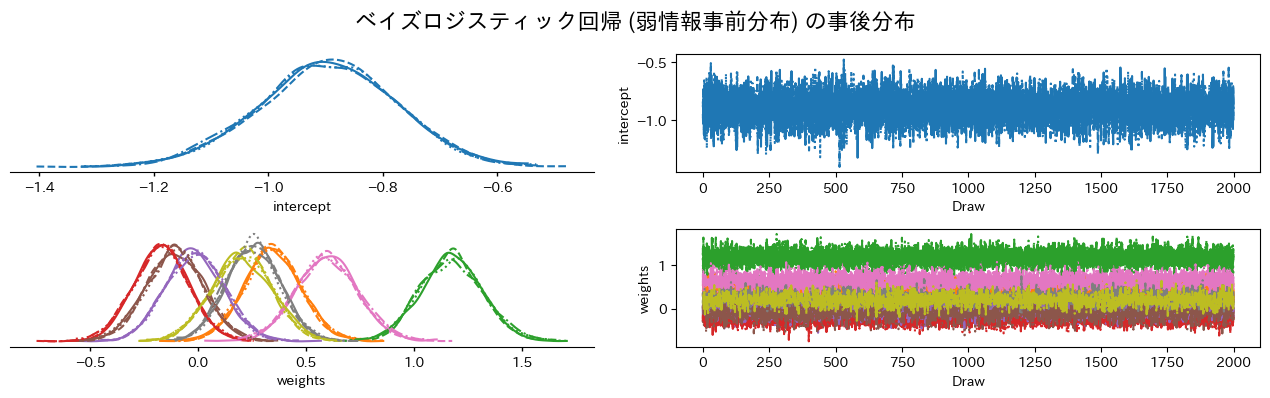

In [8]:
# arvizによる事後分布の可視化
az_data = az.from_numpyro(mcmc_flat)
az.plot_trace_dist(az_data, var_names=["intercept", "weights"], kind="kde")
plt.suptitle("ベイズロジスティック回帰 (弱情報事前分布) の事後分布", fontsize=16)
plt.tight_layout()
plt.show();

In [9]:
# ── モデル 2: 階層的事前分布 ──
mcmc_hier = run_mcmc(
    bayesian_logistic_regression_hierarchical,
    X_train_s, y_train,
    num_warmup=10000,
    model_name="Bayesian Logistic Regression (Hierarchical / Horseshoe-like Prior)"
)


  Bayesian Logistic Regression (Hierarchical / Horseshoe-like Prior) — MCMC (NUTS) 開始
  warmup=10000, samples=2000, chains=4


sample: 100%|██████████| 12000/12000 [00:05<00:00, 2011.79it/s, 31 steps of size 1.13e-01. acc. prob=0.91]


                    mean       std    median      5.0%     95.0%     n_eff     r_hat
     intercept     -0.88      0.12     -0.88     -1.08     -0.69   8184.29      1.00
        lam[0]      0.82      0.51      0.72      0.09      1.57   5539.72      1.00
        lam[1]      1.47      0.57      1.40      0.53      2.34   5075.66      1.00
        lam[2]      0.55      0.48      0.41      0.00      1.21   5411.04      1.00
        lam[3]      0.46      0.46      0.31      0.00      1.09   5812.45      1.00
        lam[4]      0.50      0.47      0.35      0.00      1.18   5678.53      1.00
        lam[5]      1.05      0.53      0.95      0.26      1.83   5400.74      1.00
        lam[6]      0.67      0.50      0.55      0.00      1.35   5141.82      1.00
        lam[7]      0.62      0.50      0.50      0.00      1.31   6024.48      1.00
           tau      0.68      0.31      0.61      0.25      1.12   2626.70      1.00
weights_raw[0]      0.83      0.52      0.72      0.13      1.67

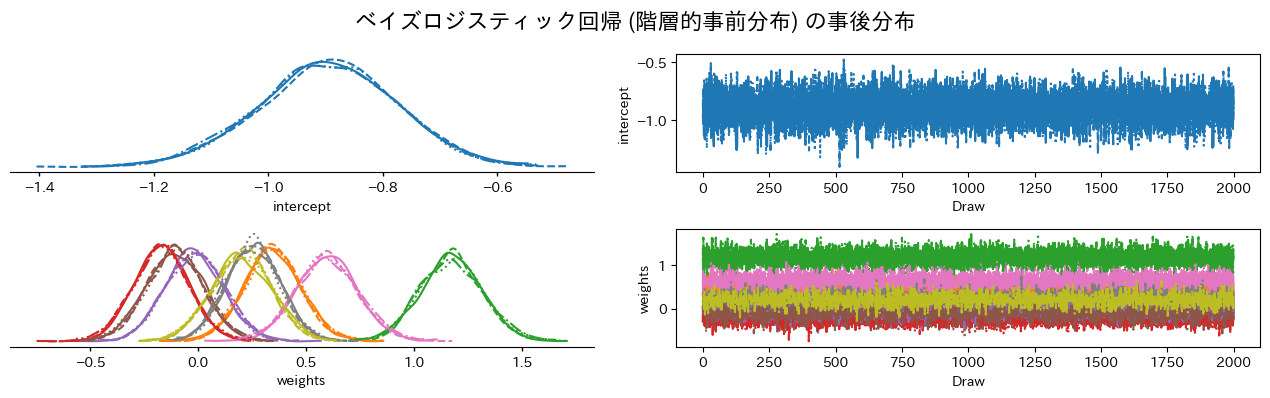

In [10]:
# arvizによる事後分布の可視化
az_data = az.from_numpyro(mcmc_flat)
az.plot_trace_dist(az_data, var_names=["intercept", "weights"], kind="kde")
plt.suptitle("ベイズロジスティック回帰 (階層的事前分布) の事後分布", fontsize=16)
plt.tight_layout()
plt.show();

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. 予測関数
# ─────────────────────────────────────────────────────────────────────────────
def predict_proba(model, mcmc, X_new, rng_key):
    """事後予測分布からの確率サンプル → 平均を予測確率として返す"""
    predictive = Predictive(model, posterior_samples=mcmc.get_samples())
    X_jnp = jnp.array(X_new, dtype=jnp.float32)
    preds = predictive(rng_key, X=X_jnp)
    # preds["y"]: shape (num_samples, n)  — 0/1 サンプル
    # sigmoid(logits) を直接計算する方が滑らか
    weights   = mcmc.get_samples()["weights"]    # (S, D)
    intercept = mcmc.get_samples()["intercept"]  # (S,)
    logits = X_jnp @ weights.T + intercept  # (n, S)
    probs  = jax.nn.sigmoid(logits)             # (n, S)
    return np.array(probs)  # (n, S)

In [12]:
def evaluate(probs_ns, y_true, split_name=""):
    """(n, S) の確率行列から評価指標を計算"""
    prob_mean = probs_ns.mean(axis=1)         # 事後平均
    y_pred    = (prob_mean >= 0.5).astype(int)

    auc  = roc_auc_score(y_true, prob_mean)
    acc  = accuracy_score(y_true, y_pred)
    nll  = log_loss(y_true, prob_mean)

    print(f"\n--- {split_name} ---")
    print(f"  AUC-ROC      : {auc:.4f}")
    print(f"  Accuracy     : {acc:.4f}")
    print(f"  Log-loss     : {nll:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=["No Diabetes", "Diabetes"]))
    return {"auc": auc, "acc": acc, "nll": nll,
            "prob_mean": prob_mean, "y_pred": y_pred, "probs_ns": probs_ns}

In [13]:
rng_pred = jax.random.PRNGKey(SEED + 1)

print("\n\n========== モデル 1: 弱情報事前分布 ==========")
probs_val_flat  = predict_proba(bayesian_logistic_regression, mcmc_flat, X_val_s,  rng_pred)
probs_test_flat = predict_proba(bayesian_logistic_regression, mcmc_flat, X_test_s, rng_pred)
res_val_flat  = evaluate(probs_val_flat,  y_val,  "Validation")
res_test_flat = evaluate(probs_test_flat, y_test, "Test")

print("\n\n========== モデル 2: 階層的事前分布 ==========")
probs_val_hier  = predict_proba(bayesian_logistic_regression_hierarchical, mcmc_hier, X_val_s,  rng_pred)
probs_test_hier = predict_proba(bayesian_logistic_regression_hierarchical, mcmc_hier, X_test_s, rng_pred)
res_val_hier  = evaluate(probs_val_hier,  y_val,  "Validation")
res_test_hier = evaluate(probs_test_hier, y_test, "Test")



========== モデル 1: 弱情報事前分布 ==========

--- Validation ---
  AUC-ROC      : 0.8238
  Accuracy     : 0.7607
  Log-loss     : 0.4876
              precision    recall  f1-score   support

 No Diabetes       0.77      0.90      0.83       107
    Diabetes       0.72      0.50      0.59        56

    accuracy                           0.76       163
   macro avg       0.75      0.70      0.71       163
weighted avg       0.75      0.76      0.75       163


--- Test ---
  AUC-ROC      : 0.8649
  Accuracy     : 0.7931
  Log-loss     : 0.4515
              precision    recall  f1-score   support

 No Diabetes       0.80      0.89      0.84        72
    Diabetes       0.78      0.64      0.70        44

    accuracy                           0.79       116
   macro avg       0.79      0.76      0.77       116
weighted avg       0.79      0.79      0.79       116



========== モデル 2: 階層的事前分布 ==========

--- Validation ---
  AUC-ROC      : 0.8226
  Accuracy     : 0.7546
  Log-loss     : 0.492


✓ 図を bayesian_glm_diabetes_results.png に保存しました


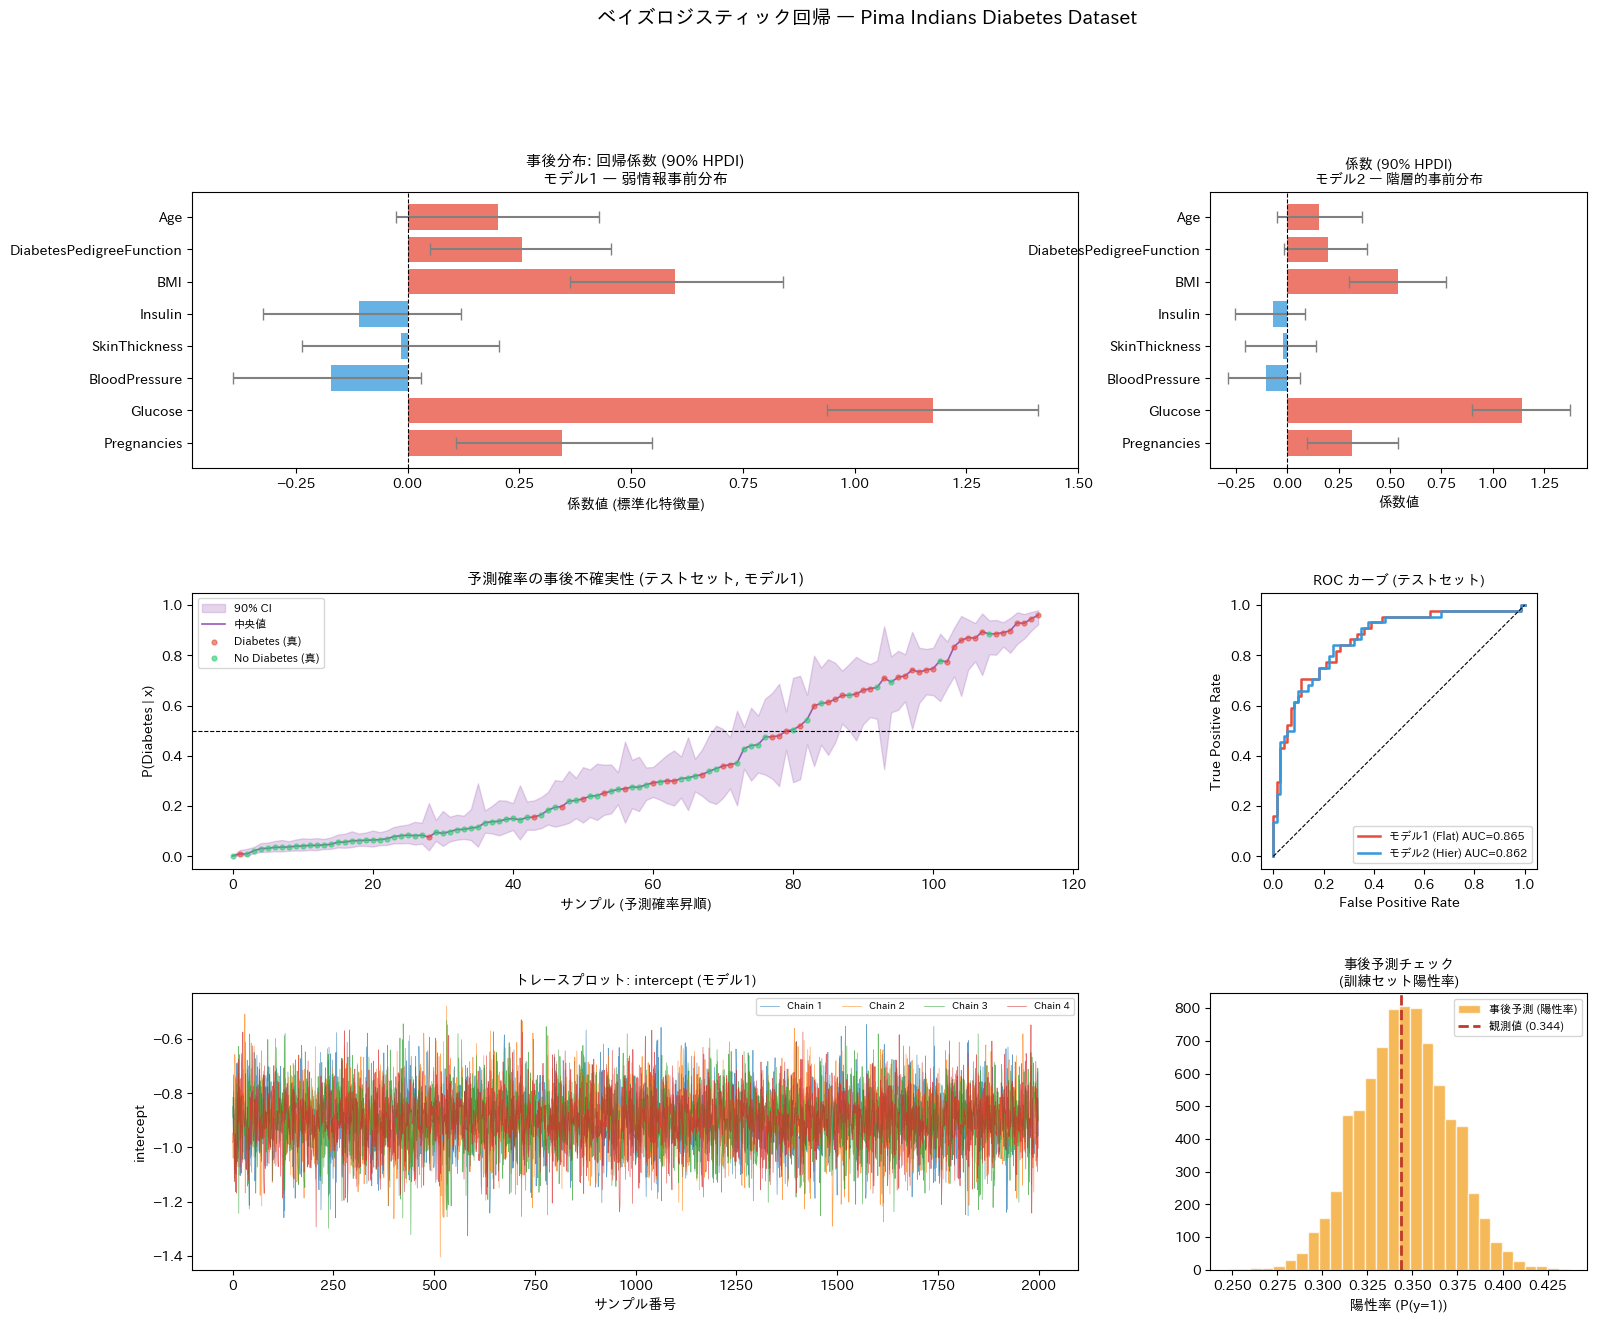

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. 可視化
# ─────────────────────────────────────────────────────────────────────────────
samples_flat = mcmc_flat.get_samples()
samples_hier = mcmc_hier.get_samples()

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (A) 事後分布: 回帰係数 (モデル1) ──
ax_a = fig.add_subplot(gs[0, :2])
w_samples = np.array(samples_flat["weights"])   # (S, D)
w_mean = w_samples.mean(axis=0)
w_hpdi = hpdi(w_samples, prob=0.9)              # (2, D)

colors = ["#e74c3c" if w_mean[i] > 0 else "#3498db" for i in range(len(FEATURE_COLS))]
ax_a.barh(FEATURE_COLS, w_mean, xerr=[w_mean - w_hpdi[0], w_hpdi[1] - w_mean],
          color=colors, alpha=0.75, capsize=4, ecolor="gray")
ax_a.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax_a.set_title("事後分布: 回帰係数 (90% HPDI)\nモデル1 — 弱情報事前分布",
               fontsize=11, fontweight="bold")
ax_a.set_xlabel("係数値 (標準化特徴量)")

# ── (B) 事後分布: 回帰係数 (モデル2) ──
ax_b = fig.add_subplot(gs[0, 2])
w2_samples = np.array(samples_hier["weights"])
w2_mean = w2_samples.mean(axis=0)
w2_hpdi = hpdi(w2_samples, prob=0.9)

colors2 = ["#e74c3c" if w2_mean[i] > 0 else "#3498db" for i in range(len(FEATURE_COLS))]
ax_b.barh(FEATURE_COLS, w2_mean, xerr=[w2_mean - w2_hpdi[0], w2_hpdi[1] - w2_mean],
          color=colors2, alpha=0.75, capsize=4, ecolor="gray")
ax_b.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax_b.set_title("係数 (90% HPDI)\nモデル2 — 階層的事前分布", fontsize=10, fontweight="bold")
ax_b.set_xlabel("係数値")

# ── (C) 予測確率の事後不確実性 (テストセット) ──
ax_c = fig.add_subplot(gs[1, :2])
sort_idx  = np.argsort(res_test_flat["prob_mean"])
prob_s    = res_test_flat["probs_ns"][sort_idx]   # (n_test, S)
prob_lo   = np.percentile(prob_s, 5,  axis=1)
prob_hi   = np.percentile(prob_s, 95, axis=1)
prob_med  = np.median(prob_s, axis=1)
x_ax      = np.arange(len(sort_idx))
y_true_s  = y_test[sort_idx]

ax_c.fill_between(x_ax, prob_lo, prob_hi, alpha=0.25, color="#9b59b6", label="90% CI")
ax_c.plot(x_ax, prob_med, color="#9b59b6", lw=1.2, label="中央値")
ax_c.scatter(x_ax[y_true_s == 1], prob_med[y_true_s == 1],
             s=12, color="#e74c3c", zorder=3, alpha=0.6, label="Diabetes (真)")
ax_c.scatter(x_ax[y_true_s == 0], prob_med[y_true_s == 0],
             s=12, color="#2ecc71", zorder=3, alpha=0.6, label="No Diabetes (真)")
ax_c.axhline(0.5, color="black", lw=0.8, ls="--")
ax_c.set_title("予測確率の事後不確実性 (テストセット, モデル1)", fontsize=11, fontweight="bold")
ax_c.set_xlabel("サンプル (予測確率昇順)")
ax_c.set_ylabel("P(Diabetes | x)")
ax_c.legend(fontsize=8, loc="upper left")
ax_c.set_ylim(-0.05, 1.05)

# ── (D) ROC カーブ比較 ──
from sklearn.metrics import roc_curve
ax_d = fig.add_subplot(gs[1, 2])
for label, prob, col in [
    ("モデル1 (Flat)",  res_test_flat["prob_mean"], "#e74c3c"),
    ("モデル2 (Hier)",  res_test_hier["prob_mean"], "#3498db"),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax_d.plot(fpr, tpr, color=col, lw=1.8, label=f"{label} AUC={auc:.3f}")
ax_d.plot([0, 1], [0, 1], "k--", lw=0.8)
ax_d.set_title("ROC カーブ (テストセット)", fontsize=10, fontweight="bold")
ax_d.set_xlabel("False Positive Rate")
ax_d.set_ylabel("True Positive Rate")
ax_d.legend(fontsize=8)
ax_d.set_aspect("equal")

# ── (E) トレースプロット (intercept) ──
ax_e = fig.add_subplot(gs[2, :2])
intercept_chains = np.array(samples_flat["intercept"]).reshape(4, -1)  # (chains, S/chains)
for ch_idx, chain in enumerate(intercept_chains):
    ax_e.plot(chain, lw=0.5, alpha=0.7, label=f"Chain {ch_idx+1}")
ax_e.set_title("トレースプロット: intercept (モデル1)", fontsize=10, fontweight="bold")
ax_e.set_xlabel("サンプル番号")
ax_e.set_ylabel("intercept")
ax_e.legend(fontsize=7, loc="upper right", ncol=4)

# ── (F) 事後予測チェック ──
ax_f = fig.add_subplot(gs[2, 2])
# モデルが予測する y=1 の割合の分布 vs 観測値
predictive_flat = Predictive(bayesian_logistic_regression,
                              posterior_samples=samples_flat)
pp_samples = predictive_flat(jax.random.PRNGKey(SEED+2),
                              X=jnp.array(X_train_s))["y"]  # (S, n_train)
pp_mean_rate = np.array(pp_samples).mean(axis=1)  # 各サンプルの陽性率
obs_rate = y_train.mean()

ax_f.hist(pp_mean_rate, bins=30, color="#f39c12", alpha=0.7,
          edgecolor="white", label="事後予測 (陽性率)")
ax_f.axvline(obs_rate, color="#c0392b", lw=2.0, ls="--",
             label=f"観測値 ({obs_rate:.3f})")
ax_f.set_title("事後予測チェック\n(訓練セット陽性率)", fontsize=10, fontweight="bold")
ax_f.set_xlabel("陽性率 (P(y=1))")
ax_f.legend(fontsize=8)

fig.suptitle("ベイズロジスティック回帰 — Pima Indians Diabetes Dataset",
             fontsize=14, fontweight="bold", y=1.01)

plt.savefig("bayesian_glm_diabetes_results.png", dpi=150, bbox_inches="tight")
print("\n✓ 図を bayesian_glm_diabetes_results.png に保存しました")

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. 要約表示
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  最終評価サマリー (テストセット)")
print("="*60)
print(f"{'モデル':<30} {'AUC':>8} {'Accuracy':>10} {'Log-loss':>10}")
print("-"*60)
print(f"{'弱情報事前分布 (Flat)':<30} "
      f"{res_test_flat['auc']:>8.4f} "
      f"{res_test_flat['acc']:>10.4f} "
      f"{res_test_flat['nll']:>10.4f}")
print(f"{'階層的事前分布 (Horseshoe-like)':<30} "
      f"{res_test_hier['auc']:>8.4f} "
      f"{res_test_hier['acc']:>10.4f} "
      f"{res_test_hier['nll']:>10.4f}")
print("="*60)


  最終評価サマリー (テストセット)
モデル                                 AUC   Accuracy   Log-loss
------------------------------------------------------------
弱情報事前分布 (Flat)                   0.8649     0.7931     0.4515
階層的事前分布 (Horseshoe-like)         0.8617     0.8017     0.4568
